[[ 23.39252222  -2.49124497 -16.59236347 ...  -6.          66.6582488
   66.92292447]
 [ 21.634483    -4.54481771 -15.98779959 ...  -6.          66.9854399
   66.91476225]
 [ 19.87644377  -6.59839046 -15.38323572 ...  -6.          66.11367204
   66.32205132]
 ...
 [-19.87644377   6.59839046  15.38323572 ...   6.          66.44276274
   66.37962399]
 [-21.634483     4.54481771  15.98779959 ...   6.          66.53927263
   66.85740976]
 [-23.39252222   2.49124497  16.59236347 ...   6.          66.81627247
   66.2297203 ]]


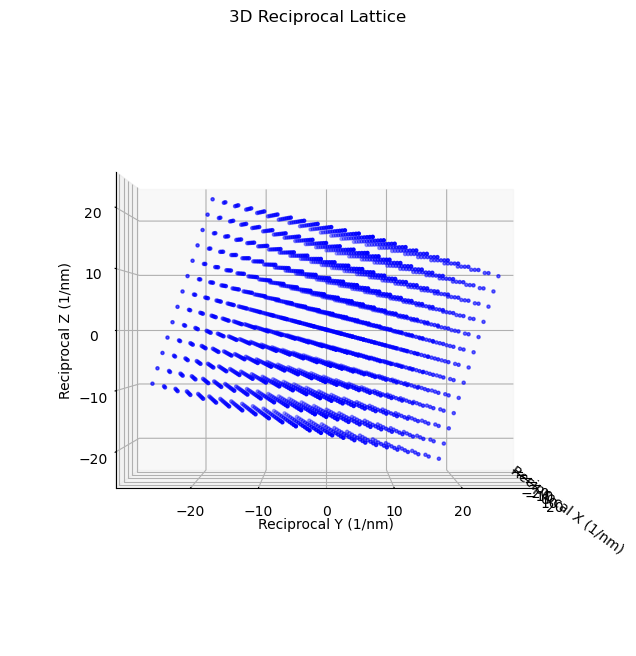

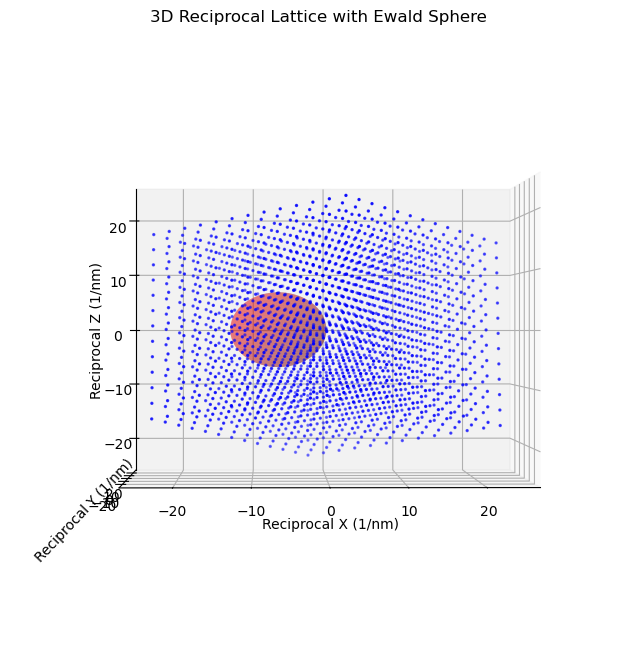

[[ 0.          0.          0.          0.          0.          0.
  66.65331914 66.5341143   6.49350649]]
   Reciprocal X (1/nm)  Reciprocal Y (1/nm)  Reciprocal Z (1/nm)    H    K  \
0                  0.0                  0.0                  0.0  0.0  0.0   

     L  grain size  grain strain  distance from the center  
0  0.0   66.653319     66.534114                  6.493506  
[ 0.          0.          0.          0.          0.          0.
 66.65331914 66.5341143   6.49350649]
[300.           0.           0.           0.           0.
   0.          66.65331914  66.5341143 ]
[[300.           0.           0.           0.           0.
    0.          66.65331914  66.5341143 ]]

Projected points on detector (within boundaries):
[[300.           0.           0.           0.           0.
    0.          66.65331914  66.5341143 ]]


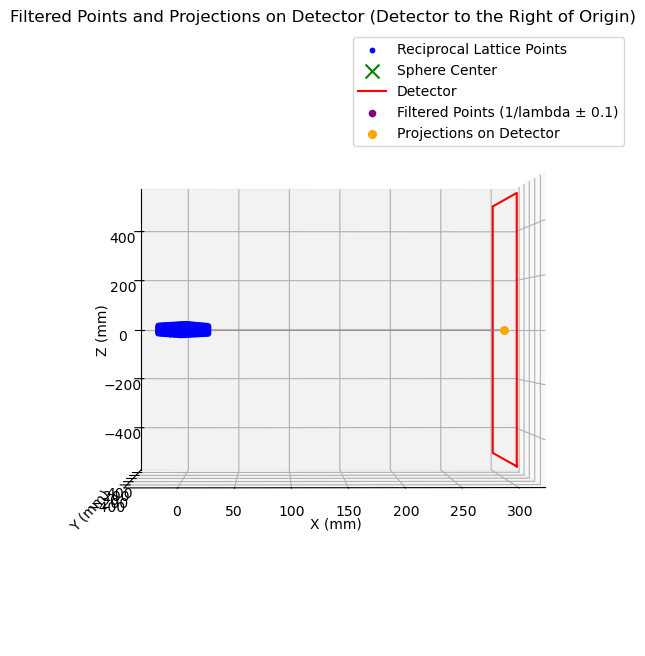

all projected points [[ 300.            0.            0.            0.            0.
     0.        ]
 [ 300.            0.            0.            0.            0.
     0.        ]
 [ 300.         -457.04306286  124.46493164    0.           -2.
    -1.        ]
 ...
 [ 300.         -141.68796931  -28.69971574   -4.           -2.
     1.        ]
 [ 300.          142.05041229  162.40988752    0.           -1.
     1.        ]
 [ 300.            0.            0.            0.            0.
     0.        ]]


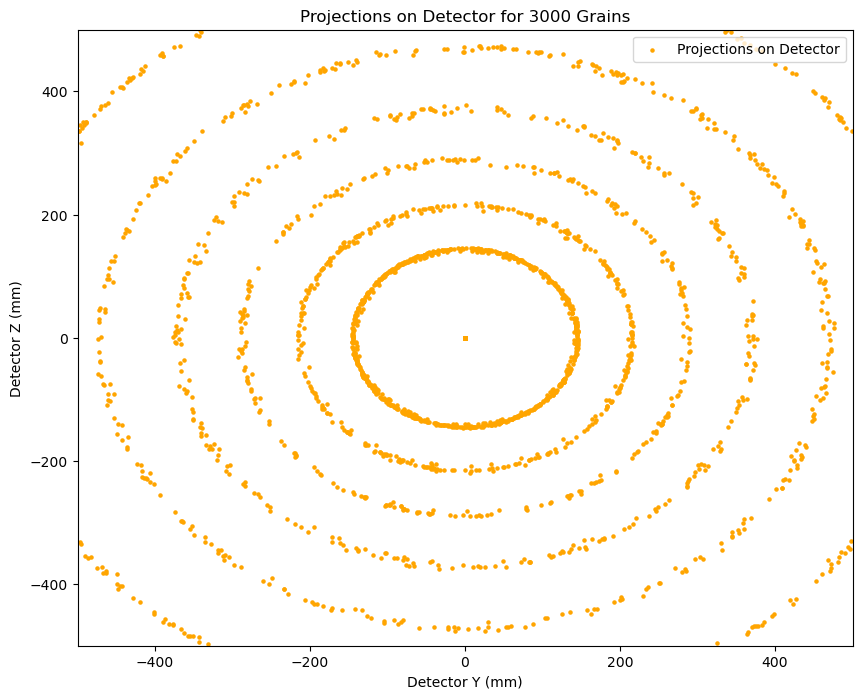

In [475]:
'''
Harrison Park : Started November 12th

The following code was made for a research collaboration with Wei Chen. 

First, it defines a material's reciprocal lattice to a certain degree based on the energy/wavelength of the X-rays being used. The reciprocal
space lattice is defined using a structure factor equation. This ensures that any extinctions are considered, and that intensities are 
correctly calculated. 

Then it defines a grain structure. It does this by creating N number of grains, each with a random orientation. This random orientation
can be adjusted to account for material texture. This is done by creating Gaussian probability distributions with peaks centered around
the preferred peaks. 

For each of these grains, an Ewald sphere center is defined at a distance 1/lambda away from the origin. Then, any reciprocal lattice points
that are on the Ewald sphere (with some margin for error) are counted. This is calculated with the Euclidean distance formula. The margin for
error also accounts for level of intensity. 

These points are projected from the Ewald sphere to the detector at an intensity calculated by the structure factor. The size of the projected
points is defined by Debye Scherrer, but also grain size. The intensity is a normal distribution. 

Projected points are aggregated over all grains and placed on the detector based on detector size. 
'''

#import dependencies. Some of these may be legacy from the original development of the code. Consider truncating.
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math 
import pandas as pd 
import numpy as np
import StructureFactors
from scipy.ndimage import convolve
from matplotlib.colors import Normalize, LogNorm



#Define the inputs
Wavelength = 0.154 #nm. Defines the wavelength of the machine. 
Material = 'Copper' #This line doesn't actually do anything, but is good for record keeping
Lattice_Parameter = 0.361 #nm. Defines the lattice parameter of the material. 

# Define detector dimensions and position (to the right of the origin)
detector_distance = 300  # mm from the origin along the X-axis
detector_width = 1000  # mm (width of the detector)
detector_height = 1000  # mm (height of the detector)

tolerance = 0.03  # +/- tolerance. Determines the spread of the points in the 2Theta direction of the rings. 
# Distance target and tolerance
lambda_inv = 1 / Wavelength
distance_target = lambda_inv #* (2 * np.pi)  # 1/lambda2pi is not included because it is already encoded into the structure factor....? 

'''
Create a Reciprocal Lattice with sphere range 
'''

''' Radius is currently set to 1/lambda, which represents the limiting sphere. . I will set this to be the size of the limiting sphere of the Ewald sphere description in order to limit the created reciprocal lattice to size'''

# Create a reciprocal lattice for a single grain
Sphere_Range = math.floor(1/Wavelength)
Indices_for_Reciprocal_Lattice = [(h, k, l) for h in range(Sphere_Range) for k in range(Sphere_Range) for l in range(Sphere_Range)] 

# Function to create a reciprocal lattice in its default orientation
def generate_reciprocal_lattice(lattice_parameter, sphere_range):
    Indices_for_Reciprocal_Lattice = [
        (h, k, l)
        for h in range(-sphere_range, sphere_range + 1)
        for k in range(-sphere_range, sphere_range + 1)
        for l in range(-sphere_range, sphere_range + 1)
        if h**2 + k**2 + l**2 <= sphere_range**2  # Limit points within the limiting sphere (accessible regimes by Edwald Sphere at all orientations)
    ]
    
    Reciprocal_Lattice_Vectors = [
        (
            h / lattice_parameter,
            k / lattice_parameter,
            l / lattice_parameter
        )
        for h, k, l in Indices_for_Reciprocal_Lattice
    ]
    return np.array(Reciprocal_Lattice_Vectors)

def generate_reciprocal_lattice_with_hkl_grainsize_grainstrain(lattice_parameter, sphere_range):
    """
    Generate reciprocal lattice vectors (x, y, z) along with their H, K, L values.
    Returns an array of shape (N, 6):
       [x, y, z, h, k, l]
    """
    hkl_range = np.arange(-sphere_range, sphere_range + 1)
    hkl_combinations = np.array(np.meshgrid(hkl_range, hkl_range, hkl_range)).T.reshape(-1, 3)
    reciprocal_lattice_vectors = hkl_combinations * (1 / lattice_parameter)
    
    grain_size = np.random.uniform(66, 67, reciprocal_lattice_vectors.shape[0])   # 66 to 67
    grain_strain = np.random.uniform((66), 67, reciprocal_lattice_vectors.shape[0])  # 66 to 67
    # Convert them to 2D so they can be column-stacked
    grain_size = grain_size[:, np.newaxis]
    grain_strain = grain_strain[:, np.newaxis]

    # Combine x, y, z with h, k, l
    reciprocal_lattice_with_hkl_grainsize_grainstrain = np.hstack((reciprocal_lattice_vectors, hkl_combinations, grain_size, grain_strain))

    return reciprocal_lattice_with_hkl_grainsize_grainstrain

def rotate_lattice(reciprocal_lattice_with_hkl, theta, phi):
    """
    Rotate the reciprocal lattice using two angles:
    - theta: Rotation around the z-axis
    - phi:   Rotation around the x-axis
    """
    # Extract (x, y, z) coordinates
    reciprocal_lattice = reciprocal_lattice_with_hkl[:, :3]
    
    # Rotation matrix around the z-axis
    Rz = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1]
    ])
    
    # Rotation matrix around the x-axis
    Rx = np.array([
        [1,         0,              0],
        [0, np.cos(phi), -np.sin(phi)],
        [0, np.sin(phi),  np.cos(phi)]
    ])
    
    # Combined rotation: apply Rz first, then Rx
    R = Rx @ Rz
    
    # Rotate the lattice points
    rotated_lattice = reciprocal_lattice @ R.T
    #return rotated_lattice 
    # Combine rotated (x, y, z) with original h, k, l
    rotated_lattice_with_hkl_grainsize_grainstrain = np.hstack((rotated_lattice, reciprocal_lattice_with_hkl[:, 3:]))
    return rotated_lattice_with_hkl_grainsize_grainstrain

# Example usage for the sake of debugging. 
if __name__ == "__main__":
    # Random angles in radians
    #Angles are currently random, but we may consider applying an ODF to be able to encode texture into the material. 
    theta = np.radians(np.random.uniform(0, 360))  # rotate around z
    phi   = np.radians(np.random.uniform(0, 360))  # rotate around x

    # Generate reciprocal lattice
    lattice_parameter = 0.361 #For some reason, this doesn't work if I put it at the start of the code..? likely due to the if __name__ == "__main__"
    Reciprocal_Lattice_With_HKL = generate_reciprocal_lattice_with_hkl_grainsize_grainstrain(lattice_parameter, Sphere_Range)

    # Separate coordinates from hkl
    reciprocal_lattice_vectors = Reciprocal_Lattice_With_HKL[:, :3]
    hkl_values = Reciprocal_Lattice_With_HKL[:, 3:]

    # Rotate coordinates
    rotated_lattice_vectors = rotate_lattice(reciprocal_lattice_vectors, theta, phi)

    # Option A: Just keep (x', y', z', h, k, l)
    Rotated_Lattice_With_HKL = np.hstack((rotated_lattice_vectors, hkl_values))

    # Option B: Also append columns for theta, phi (same for each row)
    # theta_col = np.full((rotated_lattice_vectors.shape[0], 1), theta)
    # phi_col   = np.full((rotated_lattice_vectors.shape[0], 1), phi)
    # Rotated_Lattice_With_HKL = np.hstack((
    #     rotated_lattice_vectors,
    #     hkl_values,
    #     theta_col,
    #     phi_col
    # ))
    print(Rotated_Lattice_With_HKL)
#Visualization tool
# Plot the rotated reciprocal lattice in 3D
#    This is just a quick visualization tool, which is helpful, especially if I want to explain the code or reciprocal lattices to my Structures Class. It's a nice visualization, but not critical to the code in any way. 
if __name__ == "__main__":
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    # Extract x, y, z coordinates
    x, y, z = Rotated_Lattice_With_HKL[:, 0], Rotated_Lattice_With_HKL[:, 1], Rotated_Lattice_With_HKL[:, 2]

    # Scatter plot of the lattice points
    ax.scatter(x, y, z, c='blue', marker='o', s = 5)

    # Add labels and a title
    ax.set_xlabel("Reciprocal X (1/nm)")
    ax.set_ylabel("Reciprocal Y (1/nm)")
    ax.set_zlabel("Reciprocal Z (1/nm)")
    ax.set_title("3D Reciprocal Lattice")

    # Adjust the viewing angle
    elevation = 0  # Elevation angle in degrees (vertical rotation)
    azimuth = 0    # Azimuth angle in degrees (horizontal rotation)
    ax.view_init(elev=elevation, azim=azimuth)

    # Show the plot
    plt.show()

# Define the radius of the sphere and its center
if __name__ == "__main__":

    lambda_inv = 1 / Wavelength  # Radius of the sphere is 1/lambda
    sphere_radius = lambda_inv
    sphere_center = (-lambda_inv, 0, 0)  # Center of the sphere is 1/lambda to the left of the origin

    # Generate data for the sphere
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    sphere_x = sphere_center[0] + sphere_radius * np.outer(np.cos(u), np.sin(v))
    sphere_y = sphere_center[1] + sphere_radius * np.outer(np.sin(u), np.sin(v))
    sphere_z = sphere_center[2] + sphere_radius * np.outer(np.ones(np.size(u)), np.cos(v))

    # Plot the rotated reciprocal lattice in 3D
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Extract x, y, z coordinates
    x, y, z = Rotated_Lattice_With_HKL[:, 0], Rotated_Lattice_With_HKL[:, 1], Rotated_Lattice_With_HKL[:, 2]

    # Scatter plot of the lattice points
    ax.scatter(x, y, z, c='blue', marker='o', label='Reciprocal Lattice Points', s = 2)

    # Add the sphere to the plot
    ax.plot_surface(sphere_x, sphere_y, sphere_z, color='red', alpha=0.3)

    # Add labels and a title
    ax.set_xlabel("Reciprocal X (1/nm)")
    ax.set_ylabel("Reciprocal Y (1/nm)")
    ax.set_zlabel("Reciprocal Z (1/nm)")
    ax.set_title("3D Reciprocal Lattice with Ewald Sphere")

    # Adjust the viewing angle
    elevation = 0  # Elevation angle in degrees (vertical rotation)
    azimuth = 269# Azimuth angle in degrees (horizontal rotation)
    ax.view_init(elev=elevation, azim=azimuth)

    # Show the plot
    plt.show()

'''I'm not really sure why I did this part with pandas when everything else is in numpy... consider changing'''

# Assuming Rotated_Lattice is already defined as an array of reciprocal lattice vectors
# Example: Replace this with your actual Rotated_Lattice data
# Rotated_Lattice = np.array([[x1, y1, z1], [x2, y2, z2], ...])

# Calculate the distances of all reciprocal lattice points from the sphere center
distances_from_center = np.sqrt(
    (Rotated_Lattice_With_HKL[:, 0] - sphere_center[0])**2 +
    (Rotated_Lattice_With_HKL[:, 1] - sphere_center[1])**2 +
    (Rotated_Lattice_With_HKL[:, 2] - sphere_center[2])**2
)

Rotated_Lattice_with_HKL_and_Distances_from_Center = np.hstack((Rotated_Lattice_With_HKL, distances_from_center.reshape(-1, 1)))


# Find all points within the target distance range
# Create the mask for rows whose 7th column is within [distance_target - tolerance, distance_target + tolerance]
mask = (
    (Rotated_Lattice_with_HKL_and_Distances_from_Center[:, 8] >= distance_target - tolerance) &
    (Rotated_Lattice_with_HKL_and_Distances_from_Center[:, 8] <= distance_target + tolerance)
)

filtered_points = Rotated_Lattice_with_HKL_and_Distances_from_Center[mask]
print(filtered_points)

# # Combine the filtered points with their distances
# print(filtered_points_with_distances)
# filtered_points_with_distances = np.hstack((filtered_points, distances_from_center[mask].reshape(-1, 1)),Rotated_Lattice_With_HKL[:,1])

# Convert to a labeled DataFrame for clarity. This was an early attemp at the code that uses pandas, but in later iterations, I've moved away from using dataframes and instead use  numpy arrays. This part of the code should actually be fairly redundant, and  would be okay to delete. 
#Is it actually important to encode the distance from the center here? I guess it would actually help with the proportional aspect of this... 
columns = ["Reciprocal X (1/nm)", "Reciprocal Y (1/nm)", "Reciprocal Z (1/nm)", "H", "K", "L", "grain size", "grain strain","distance from the center"]
filtered_points_df = pd.DataFrame(filtered_points, columns=columns)

# Print the filtered points (optional)
print(filtered_points_df)

# Save to a CSV file (optional)
filtered_points_df.to_csv("filtered_points_near_distance.csv", index=False)

detector_center = (detector_distance, 0, 0)  # Center of the detector in 3D space (to the right)

projected_points = []

'''code testing ground for projecting points in "filtered points" onto a detector. '''
for point in filtered_points:
    # Only the first three elements of `point` are (x, y, z)
    print(point)
    xyz_coords = point[:3]
    HKL = point[3:6]
    grainsize = point[6]
    grainstrain = point[7]
    distance = point[8]
    
    # Direction vector from sphere center to the point
    direction_vector = xyz_coords - np.array(sphere_center)
    
    # Scale factor to extend the vector so X crosses detector_distance
    # (plane at x = detector_distance)
    scale_factor = (detector_distance - sphere_center[0]) / direction_vector[0]
    
    # Calculate the projection on that plane
    projected_point = np.array(sphere_center) + scale_factor * direction_vector
    projected_point = np.hstack((projected_point, HKL,grainsize, grainstrain))
    print(projected_point)

    # Check if the projected point is within the detector boundaries in y,z
    if (
        -detector_width / 2  <= projected_point[1] <= detector_width / 2  and
        -detector_height / 2 <= projected_point[2] <= detector_height / 2
    ):
        projected_points.append(projected_point)


# Convert to NumPy array for easy manipulation (if needed)
projected_points = np.array(projected_points)
print(projected_points)

print("\nProjected points on detector (within boundaries):")
print(projected_points)
# Create a 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot reciprocal lattice points
ax.scatter(Rotated_Lattice_With_HKL[:, 0], Rotated_Lattice_With_HKL[:, 1], Rotated_Lattice_With_HKL[:, 2], c='blue', label='Reciprocal Lattice Points', s=10)

# Plot the sphere center
ax.scatter(sphere_center[0], sphere_center[1], sphere_center[2], c='green', marker='x', s=100, label='Sphere Center')

# Plot the detector rectangle
detector_corners = np.array([
    [detector_distance, -detector_width / 2, -detector_height / 2],
    [detector_distance, detector_width / 2, -detector_height / 2],
    [detector_distance, detector_width / 2, detector_height / 2],
    [detector_distance, -detector_width / 2, detector_height / 2],
])
detector_x = [corner[0] for corner in detector_corners] + [detector_corners[0][0]]
detector_y = [corner[1] for corner in detector_corners] + [detector_corners[0][1]]
detector_z = [corner[2] for corner in detector_corners] + [detector_corners[0][2]]
ax.plot(detector_x, detector_y, detector_z, color='red', label='Detector')

# Plot the filtered points
ax.scatter(filtered_points[:, 0], filtered_points[:, 1], filtered_points[:, 2], c='purple', label='Filtered Points (1/lambda ± 0.1)', s=20)

# Plot the projections on the detector
if len(projected_points) > 0:
    ax.scatter(projected_points[:, 0], projected_points[:, 1], projected_points[:, 2], c='orange', label='Projections on Detector', s=30)

# Draw lines from sphere center through filtered points to detector
for point, proj in zip(filtered_points, projected_points):
    ax.plot([sphere_center[0], point[0], proj[0]],
            [sphere_center[1], point[1], proj[1]],
            [sphere_center[2], point[2], proj[2]], color='gray', alpha=0.5)

# Add labels and legend
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.set_zlabel("Z (mm)")
ax.set_title("Filtered Points and Projections on Detector (Detector to the Right of Origin)")
ax.legend()

# Set viewing angle
ax.view_init(elev=0, azim=269)

plt.show()

# Generate reciprocal lattice
Reciprocal_Lattice_with_HKL_grainsize_grainstrain = generate_reciprocal_lattice_with_hkl_grainsize_grainstrain(Lattice_Parameter, Sphere_Range)


# Function to project points onto the detector
def project_points(Reciprocal_Lattice_with_HKL_grainsize_grainstrain, sphere_center):
    projected_points = []
    for point in Reciprocal_Lattice_with_HKL_grainsize_grainstrain:
        direction_vector = point[:3] - np.array(sphere_center)
        scale_factor = (detector_distance - sphere_center[0]) / direction_vector[0]
        projected_point = np.array(sphere_center) + scale_factor * direction_vector
        if (
            -detector_width / 2 <= projected_point[1] <= detector_width / 2 and
            -detector_height / 2 <= projected_point[2] <= detector_height / 2
        ):
            
            point_with_hkl = np.concatenate((projected_point, point[3:6]))
            projected_points.append(point_with_hkl)
            
    return np.array(projected_points)

# Number of grains
num_grains = int(input("Enter the number of grains: "))

# Aggregate projections from all grains
all_projected_points = []  # Initialize as a list to collect all projections

for _ in range(num_grains):
    # Generate random orientations
    theta = np.radians(np.random.uniform(0, 360))
    phi = np.radians(np.random.uniform(0, 360))
    
    # Rotate reciprocal lattice
    rotated_lattice = rotate_lattice(Reciprocal_Lattice_with_HKL_grainsize_grainstrain, theta, phi)
    
    # Calculate distances from the center
    distances_from_center = np.sqrt(
        (rotated_lattice[:, 0] - sphere_center[0])**2 +
        (rotated_lattice[:, 1] - sphere_center[1])**2 +
        (rotated_lattice[:, 2] - sphere_center[2])**2
    )
    
    # Add distances to the rotated lattice array (if needed)
    rotated_lattice_with_distances = np.hstack((rotated_lattice, distances_from_center[:, np.newaxis]))
    
    # Filter points within the specified distance range
    mask = (
        (rotated_lattice_with_distances[:, 8] >= distance_target - tolerance) &
        (rotated_lattice_with_distances[:, 8] <= distance_target + tolerance)
    )
    filtered_points = rotated_lattice_with_distances[mask]
    
    # Project onto the detector
    if filtered_points.size > 0:
        projections = project_points(filtered_points, sphere_center)
        if projections.size > 0:  # Append only if projections are valid
            all_projected_points.extend(projections)

# Convert to NumPy array after collecting all projections
all_projected_points = np.array(all_projected_points)

print('all projected points' , all_projected_points)

# Plot the projections on the detector
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)

ax.set_xlim(-detector_width / 2, detector_width / 2)
ax.set_ylim(-detector_height / 2, detector_height / 2)
ax.scatter(all_projected_points[:, 1], all_projected_points[:, 2], c='orange', s=5, label='Projections on Detector')
ax.set_xlabel("Detector Y (mm)")
ax.set_ylabel("Detector Z (mm)")
ax.set_title(f"Projections on Detector for {num_grains} Grains")
ax.legend()

plt.show()


In [476]:
'''At this print, the matrix "all projected points" is a 3rd rank tensor. [0] is the X location (distance from sample to detector), [1] is the X-coordinate, [2] is the Y-coordinate. One question that I might ask is whether or not this is a code that needs further growth... '''
detector_points_YZ = all_projected_points[:,1:3] #X is set at the detector distance, so only YZ is important
HKL_values_on_detector = all_projected_points[:,3:6] #"on detector" here doesn't mean much. just HKL indices, kept for record-keeping and further calculations
theta_values = []
#calculates the two-theta values for each of the points within the detector points. 
for i in detector_points_YZ:
    #print(detector_points[0], detector_points[1])aa
    two_theta = math.atan((((i[0])**2 + i[1]**2)**0.5)/detector_distance) # Calculates the theta angle for the material for use in calculating  the q-dependent intensity 
    theta_values.append(two_theta)
    #print(theta) 



#Watch out in this section of code for variable names lorentz_factors and lorentz_factor, which are different values and serve different functions. Could I make this better? Absolutely, and it would drastically improve my quality of life. Will I? uh.... 

#In future addition, Lorentz factors will be combined with polarization factor as well to create a general LP function 

lorentz_factors = []
for i in theta_values:
    if math.sin(i) == 0:
        lorentz_factor = 0.5
    else:
        lorentz_factor = 1/math.sin(i) 
    lorentz_factors.append(lorentz_factor)

lorentz_factors = np.array(lorentz_factors)

YZ_HKL_TwoTheta_lorentz = np.column_stack((detector_points_YZ, HKL_values_on_detector, theta_values,lorentz_factors)) #Could have done this with just projected points on detector [:,1:6], but separating enhances readability

print(YZ_HKL_TwoTheta_lorentz)



[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  5.00000000e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  5.00000000e-01]
 [-4.57043063e+02  1.24464932e+02  0.00000000e+00 ... -1.00000000e+00
   1.00623011e+00  1.18368302e+00]
 ...
 [-1.41687969e+02 -2.86997157e+01 -4.00000000e+00 ...  1.00000000e+00
   4.49050595e-01  2.30356123e+00]
 [ 1.42050412e+02  1.62409888e+02  0.00000000e+00 ...  1.00000000e+00
   6.23510816e-01  1.71265443e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  5.00000000e-01]]


In [477]:
''' multiply the structure factor by all of the points by creating a 2D grid with a delta function at each point. '''
'''use this theta to calculate the atomic scattering factor. Combine these with the structure factor. '''
CrystalStructure = input('What kind of crystal is it?')
print('crystal structure is', CrystalStructure)

import StructureFactors
structure_factor_map = {
    'SC': StructureFactors.structure_factor_sc,
    'FCC': StructureFactors.structure_factor_fcc,
    'BCC': StructureFactors.structure_factor_bcc,
    'DC': StructureFactors.structure_factor_diamond,
    'HCP': StructureFactors.structure_factor_hcp,
    'BCT': StructureFactors.structure_factor_bct,
    'FCT': StructureFactors.structure_factor_fct,
    'Orthorhombic': StructureFactors.structure_factor_orthorhombic,
    'BCO': StructureFactors.structure_factor_bco,
    'FCO': StructureFactors.structure_factor_fco,
    'Rhombohedral': StructureFactors.structure_factor_rhombohedral,
}

if CrystalStructure in structure_factor_map:
    structure_factor_func = structure_factor_map[CrystalStructure]

crystal structure is SC


In [478]:
#Convolution time!
#Add references here 
# Example usage:
# Coefficients for copper (Cu) as an example
a_cu = [3.5493, 2.6412, 1.5170, 1.0243]
b_cu = [10.2825, 4.2944, 0.2615, 26.1476]
c_cu = 0.2776

def atomic_scattering_factor(s, a, b, c):
    """
    Calculate the atomic scattering factor f(s) using atomic scattering factor coefficients.
    Parameters:
    -----------
    s : float
        Scattering vector magnitude?
    a : list of float
        List of amplitude coefficients [a1, a2, a3, a4].
    b : list of float
        List of exponential damping coefficients [b1, b2, b3, b4].
    c : float
        Constant term for the scattering factor at high s.

    Returns:
    --------
    float
        Atomic scattering factor f(s).
    """
    if len(a) != 4 or len(b) != 4:
        raise ValueError("Coefficients 'a' and 'b' must each have exactly 4 elements.")

    f_s = sum(a[i] * math.exp(-b[i] * s**2) for i in range(4)) + c
    return f_s

Intensities = []
for i in YZ_HKL_TwoTheta_lorentz:
    s = (math.sin(i[5]/2))/Wavelength 
    f_atomic_scatter = atomic_scattering_factor(s, a_cu, b_cu, c_cu)
    F = structure_factor_func(i[2],i[3],i[4], f_atomic_scatter)

#    print([YZ_HKL_TwoTheta[2],YZ_HKL_TwoTheta[3],YZ_HKL_TwoTheta[4], f])
    intensity = F * F.conjugate() #complex conjugate of the Structure Factor for Intensity
    Intensities.append(intensity)

Intensities = np.array(Intensities)
YZ_HKL_TwoTheta_FFconj = np.hstack((YZ_HKL_TwoTheta_lorentz,Intensities.reshape(-1,1)))

# Reshape into a single-column array
lorentz_factors_column = lorentz_factors.reshape(-1, 1)

lorentz_factor = np.random.uniform(1, 10, YZ_HKL_TwoTheta_FFconj.shape[0])  # 1 to 10
polarization_factor = np.random.uniform(1, 10, YZ_HKL_TwoTheta_FFconj.shape[0])  # 1 to 10
distance_factor = np.random.uniform(1, 10, YZ_HKL_TwoTheta_FFconj.shape[0])  # 1 to 10



# -----------------
# Combine everything into one array: At this point, FFconj, grain_size and grain_strain are columns. However, it would be more meaningful to actually combine all factors into intensity and FWHM calculations. 
# -----------------
YZ_HKL_TwoTheta_FFconj_grainsize_grainstrain = np.column_stack((
    YZ_HKL_TwoTheta_FFconj,
    grain_size,
    grain_strain,
    lorentz_factor,
    polarization_factor,
    distance_factor
))

print(YZ_HKL_TwoTheta_FFconj_grainsize_grainstrain) 
#An interesting artifact here is that at this point, any non-activated points are represented as having 000 hkl. Not sure why this is, should probably look back into it. 


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 5215 and the array at index 1 has size 17093

In [ ]:
# Assuming YZ_HKL_TwoTheta_FFconj is a NumPy array

# Extract X, Y, intensity values, grain size, grainstrain 
X = YZ_HKL_TwoTheta_FFconj_grainsize_grainstrain[:, 0]  # Column 1: X coordinates
Y = YZ_HKL_TwoTheta_FFconj_grainsize_grainstrain[:, 1]  # Column 2: Y coordinates
Intensity = YZ_HKL_TwoTheta_FFconj_grainsize_grainstrain[:, 7]  # Column 7: Intensity values
grain_size = YZ_HKL_TwoTheta_FFconj_grainsize_grainstrain[:, 8]  # Column 8: Intensity values
grain_strain = YZ_HKL_TwoTheta_FFconj_grainsize_grainstrain[:, 9]  # Column 9: Intensity values

# Replace negative intensities with 0 (if any exist)
Intensity = np.where(Intensity > 0, Intensity, 0)

# Mask intensity values of 0 to set them to the background color
masked_intensity = np.ma.masked_where(Intensity == 0, Intensity)

# Set normalization to range from 0 to 1, capping max at 1
norm = Normalize(vmin=0, vmax=1, clip=True)

# Create the plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X, Y, c=masked_intensity, cmap='cividis', s=50, norm=norm)
plt.colorbar(scatter, label='Intensity')  # Add colorbar for intensity
plt.title('Intensity Map (Intensity = 0 matches background)')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()


In [ ]:
# Replace negative intensities with 0
'''This part of the code generally deals with instrumental broadening'''

Intensity = np.where(Intensity > 0, Intensity, 0)

# Define the grid size and range
grid_size = 1000  # Number of bins in each dimension
x_edges = np.linspace(X.min(), X.max(), grid_size)
y_edges = np.linspace(Y.min(), Y.max(), grid_size)

# Create a 2D histogram (density map) of intensities
grid, x_edges, y_edges = np.histogram2d(X, Y, bins=[x_edges, y_edges], weights=Intensity)

# Create a 2D normal distribution kernel
sigma = 0.5  # Standard deviation of the normal distribution
kernel_size = int(10 * sigma)  # Kernel size 
x = np.linspace(-3 * sigma, 3 * sigma, kernel_size)
y = np.linspace(-3 * sigma, 3 * sigma, kernel_size)
x, y = np.meshgrid(x, y)

#Kernel issues: insert here. I want to create a... dictionary? Perhaps? Or some way of encoding grain size information with the corresponding YZ coordinates as were defined in the earlier section with variable YZ_HKL_TwoTheta_FFconj_grainsize_grainstrain. 


kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2)) #Two dimensional normal distribution equation (e^-(x^2 + y^2))f form. Isn't normalized over 2-pi...
kernel /= kernel.sum()  # Normalize the kernel

# Convolve the grid with the Gaussian kernel
convolved_grid = convolve(grid, kernel, mode='constant', cval=0)

# Replace zeros or negative values with a small positive number to avoid issues with LogNorm
epsilon = 1e-10  # Small constant to avoid log(0)
convolved_grid[convolved_grid <= 0] = epsilon

# Create the first figure: Normalized Intensity Plot
fig1, ax1 = plt.subplots(figsize=(10, 8))
extent = [x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]]
im1 = ax1.imshow(
    convolved_grid.T,
    extent=extent,
    origin='lower',
    cmap='cividis',
    vmin=convolved_grid.min(),
    vmax=convolved_grid.max(),
    aspect='auto'
)
fig1.colorbar(im1, ax=ax1, label='Convolved Intensity (Normalized)')
ax1.set_title('Convolved Intensity Map (Normalized)')
ax1.set_xlabel('X Coordinate')
ax1.set_ylabel('Y Coordinate')
plt.show()

# Create the second figure: Log-Normalized Intensity Plot
fig2, ax2 = plt.subplots(figsize=(10, 8))
im2 = ax2.imshow(
    convolved_grid.T,
    extent=extent,
    origin='lower',
    cmap='cividis',
    norm=LogNorm(vmin=convolved_grid.min(), vmax=convolved_grid.max()),
    aspect='auto'
)
fig2.colorbar(im2, ax=ax2, label='Convolved Intensity (Log Scale)')
ax2.set_title('Convolved Intensity Map (Log Scale)')
ax2.set_xlabel('X Coordinate')
ax2.set_ylabel('Y Coordinate')
plt.show()


In [ ]:
'''
Creating a function that essentially acts as a Kernel to convolve over activated peaks and make them normal distributions that take into account: 
Crystallite size: Scherrer Equation
Crystallite Strain: Williamson Hall addition
Peak broadening due to detector distance from the source (Ewald Sphere S0, S calculation)
Lorentz Factor (Transmission or reflection geometry) 
Polarization Factor (Based on X-ray source. Currently, we are assuming that MAXIMA is unpolarized even though we should consider the monochromation)
Thermal broadeneing (Should I include this)
'''
#def experimental_broadening (factors):
#

K = 0.9 #shape factor
WAVELENGTH = #lambda (previously defined)
epsilon = #epsilon, strain

lorentz_factor = 
distance_factor = 
return FWHM value 


def experimental_broadening(
    theta,            # Bragg angle in radians (array or float)
    D,                # Crystallite size (in nm, Å, or same units consistent with wavelength)
    epsilon,          # Microstrain (dimensionless)
    wavelength,       # Radiation wavelength (same units as D)
    K=0.9,            # Scherrer shape factor
    include_thermal=False, 
    thermal_params=None,
    include_detector_distance=False,
    detector_distance=1.0
):
    """
    Compute an approximate Full Width at Half Maximum (FWHM) in angular space (radians),
    combining:
      - Size broadening (Scherrer)
      - Strain broadening (Williamson-Hall)
      - Optional 'thermal broadening' term (very approximate)
      - Optional geometry factor from detector distance

    Parameters
    ----------
    theta : float or np.ndarray
        Bragg angle in radians.
    D : float
        Crystallite size.
    epsilon : float
        Microstrain (dimensionless).
    wavelength : float
        X-ray (or neutron, electron) wavelength in same length units as D.
    K : float, optional
        Scherrer shape factor, by default 0.9.
    include_thermal : bool, optional
        Whether to include a user-defined thermal broadening term, by default False.
    thermal_params : dict, optional
        Dictionary with parameters for thermal broadening model, e.g. {"A": value}, by default None.
    include_detector_distance : bool, optional
        If True, apply a geometric “magnification” factor using `detector_distance`.
    detector_distance : float, optional
        Sample-to-detector distance (in the same "unit" system that you want for FWHM output).

    Returns
    -------
    fwhm_total : float or np.ndarray
        Estimated total FWHM in either angular space (radians) or “spot size” if `include_detector_distance` is True.
    """

    # --- 1) Size Broadening (Scherrer) ---
    # Make sure theta is not zero or near zero to avoid division by cos(theta)=0 at very high angles
    beta_size = (K * wavelength) / (D * np.cos(theta))

    # --- 2) Strain Broadening (Williamson-Hall) ---
    beta_strain = 4.0 * epsilon * np.sin(theta)
    
    # Combine them (assuming simple linear addition in angle: 
    #   beta_total(θ) = beta_size + beta_strain.
    # A more common approach for final FWHM is sqrt( beta_size^2 + beta_strain^2 ).
    # BUT the standard W-H approach is linear in (beta cosθ) vs. sinθ. 
    # In typical practice, people do:
    #    beta_total^2 = beta_size^2 + beta_strain^2 + ...
    # Here, we show a naive sum-of-squares example:
    beta_total = np.sqrt(beta_size**2 + beta_strain**2)
    
    # --- 3) Optional Thermal Broadening (very approximate) ---
    if include_thermal and thermal_params is not None:
        # Suppose we have some model: beta_thermal ~ A * sin(theta) or user-defined
        A = thermal_params.get("A", 0.0)  # arbitrary parameter
        beta_thermal = A * np.sin(theta)
        beta_total = np.sqrt(beta_total**2 + beta_thermal**2)

    # --- 4) Convert to “Spot Size” if Detector Distance is considered ---
    if include_detector_distance:
        # If we want the final broadening as a "linear dimension" on the detector,
        # multiply the angular broadening (radians) by the sample-to-detector distance.
        fwhm_total = beta_total * detector_distance
    else:
        # Just the angular FWHM in radians
        fwhm_total = beta_total

    return fwhm_total

'''
Instrumental broadening:
Simple broadening kernel that affects all points equally. Normally, this kernel would be applied as a convolution over the experimental broadening. However, because of the set up of the current experiment, it might make more sense to try to create each grain (which has a unique grain size), run the physical broadening conditions, and rinse and repeat, and finally run the instrumental broadening kernel over all activated grains at the same time in order to save on computational cost. 
'''
